[PIPELINE] Chargement de YOLO depuis C:\Users\HP\Desktop\blood\runs\detect\blood_detection\detection_run\weights\best.pt...
[PIPELINE] Chargement d'EfficientNet depuis C:\Users\HP\Desktop\blood\outputs\checkpoints\classification_best.pt...
[PIPELINE] Pipeline prêt !
[INFO] Exécution du pipeline...

0: 480x640 2 WBCs, 7 RBCs, 656.5ms
Speed: 12.7ms preprocess, 656.5ms inference, 6.6ms postprocess per image at shape (1, 3, 480, 640)
[FILTRE] YOLO a détecté 9 cellules au total.
[FILTRE]   - 2 globules BLANCS (WBC) → envoyés au classifieur.
[FILTRE]   - 7 globules ROUGES (RBC) → IGNORÉS (non-classifiés).


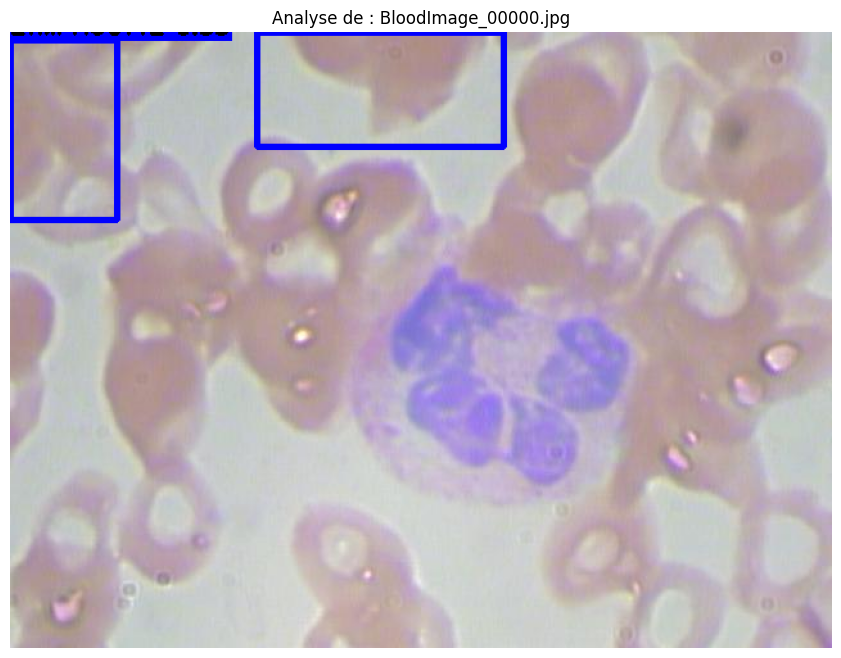


📋 RAPPORT D'ANALYSE
Total WBC : 2
    NEUTROPHIL : 0
      MONOCYTE : 0
    LYMPHOCYTE : 2
    EOSINOPHIL : 0

Ratio N/L : 0.00
Diagnostic : Ratio N/L BAS (<1.0) : Peut suggérer une infection virale ou une immuno-déficience.


In [1]:


import sys
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import json

sys.path.append(str(Path.cwd().parent))
from src.inference.pipeline import load_pipeline


PROJECT_ROOT = Path("..")
pipeline = load_pipeline()


test_image = PROJECT_ROOT / "data" / "raw" / "detection" / "bccd" / "images" / "BloodImage_00000.jpg"

if not test_image.exists():
    print(f"[ERROR] Image introuvable : {test_image}")
else:
    
    print("[INFO] Exécution du pipeline...")
    result = pipeline.predict_on_image(test_image)
    
    
    img_rgb = cv2.cvtColor(result['annotated_image'], cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title(f"Analyse de : {test_image.name}")
    plt.axis('off')
    plt.show()
    
   
    report = result['report']
    print("\n" + "=" * 50)
    print("📋 RAPPORT D'ANALYSE")
    print("=" * 50)
    print(f"Total WBC : {report['total_wbc']}")
    for cls, count in report['counts'].items():
        print(f"  {cls:>12} : {count}")
    print(f"\nRatio N/L : {report['ratio']:.2f}")
    print(f"Diagnostic : {report['interpretation']}")
    print("=" * 50)